In [4]:
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 2.9/38.1 MB 15.8 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/38.1 MB 17.1 MB/s eta 0:00:02
   ----------- ---------------------------- 11.0/38.1 MB 17.9 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/38.1 MB 18.3 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/38.1 MB 18.5 MB/s eta 0:00:02
   ------------------------ --------------- 23.6/38.1 MB 19.0 MB/s eta 0:00:01
   ----------------------------- ---------- 28.6/38.1 MB 19.8 MB/s eta 0:00:01
   ----------------------------------- ---- 34.1/38.1 MB 20.6 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 19.6 MB/s eta

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"SHAP version: {shap.__version__}")

c:\Users\Shail\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


## Data Preprocessing 

In [6]:
train = pd.read_csv('train.csv')
print(f"Raw shape: {train.shape}")

df = train.copy()
df = df.drop(columns=["Employee ID"])
df = df.dropna(subset=["Burn Rate"]).copy()

df["Date of Joining"] = pd.to_datetime(df["Date of Joining"])
df["days_since_joined"] = (pd.Timestamp("2008-12-31") - df["Date of Joining"]).dt.days
df = df.drop(columns=["Date of Joining"])

df["gender"]       = df["Gender"].map({"Male": 1, "Female": 0})
df["company_type"] = df["Company Type"].map({"Service": 1, "Product": 0})
df["is_wfh"]       = df["WFH Setup Available"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

# Probabilistic imputation (MCAR-confirmed)
rng = np.random.default_rng(RANDOM_STATE)
for col in ["Mental Fatigue Score", "Resource Allocation"]:
    mask = df[col].isna()
    df.loc[mask, col] = rng.choice(df.loc[~mask, col].values, size=mask.sum(), replace=True)

# Feature engineering
df["Workload Fatigue Interaction"] = df["Resource Allocation"] * df["Mental Fatigue Score"]
df["Fatigue Ratio"]  = df["Mental Fatigue Score"] / df["Resource Allocation"]
df["High Workload"]  = (df["Resource Allocation"] > df["Resource Allocation"].median()).astype(int)
df["High Fatigue"]   = (df["Mental Fatigue Score"] > df["Mental Fatigue Score"].median()).astype(int)
df["Stress Index"]   = 0.7 * df["Mental Fatigue Score"] + 0.3 * df["Resource Allocation"]

feature_cols = [c for c in df.columns if c != "Burn Rate"]
print(f"Processed shape: {df.shape}")
print(f"Features: {feature_cols}")

Raw shape: (22750, 9)
Processed shape: (21626, 13)
Features: ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'days_since_joined', 'gender', 'company_type', 'is_wfh', 'Workload Fatigue Interaction', 'Fatigue Ratio', 'High Workload', 'High Fatigue', 'Stress Index']


## Train Split and scaling 

In [7]:
X = df[feature_cols]
y = df["Burn Rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale features — important for GBM convergence and fair regularization
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

# Reset index so sampling aligns correctly between X and y
y_test_reset = y_test.reset_index(drop=True)

print(f"Train: {X_train_s.shape} | Test: {X_test_s.shape}")

Train: (17300, 12) | Test: (4326, 12)


## Train Gradient Boosting on Original Features

In [8]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train_s, y_train)

y_pred = gb_model.predict(X_test_s)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Gradient Boosting (Original Features) — Test Set")
print("=" * 48)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"\nBaseline (Random Forest): RMSE=0.0631, R²=0.8953")

Gradient Boosting (Original Features) — Test Set
RMSE : 0.0683
MAE  : 0.0509
R²   : 0.8775

Baseline (Random Forest): RMSE=0.0631, R²=0.8953


## Compute SHAP Values

In [9]:
# SHAP TreeExplainer
explainer = shap.TreeExplainer(gb_model)

# Sample test set for SHAP 
shap_sample = X_test_s.sample(500, random_state=RANDOM_STATE)
X_shap = shap_sample.reset_index(drop=True)
y_shap = y_test_reset.iloc[shap_sample.index].values

# Computing SHAP values shape: (n_samples, n_features)
shap_values = explainer.shap_values(X_shap, check_additivity=False)
expected_value = explainer.expected_value
# Handling SHAP versions that return expected_value as an array
if hasattr(expected_value, '__len__'):
    expected_value = float(expected_value[0])
else:
    expected_value = float(expected_value)

print(f"SHAP values shape  : {shap_values.shape}")
print(f"Baseline (expected): {expected_value:.4f}  (= mean Burn Rate in training data)")
print(f"\nSanity check — SHAP sum + expected ≈ prediction:")
for i in range(3):
    shap_pred = expected_value + shap_values[i].sum()
    model_pred = gb_model.predict(X_shap.iloc[[i]])[0]
    print(f"  Sample {i}: SHAP sum+base={shap_pred:.4f} | Model pred={model_pred:.4f} | Match: {abs(shap_pred-model_pred)<0.01}")

SHAP values shape  : (500, 12)
Baseline (expected): 0.4522  (= mean Burn Rate in training data)

Sanity check — SHAP sum + expected ≈ prediction:
  Sample 0: SHAP sum+base=0.5111 | Model pred=0.5111 | Match: True
  Sample 1: SHAP sum+base=0.4174 | Model pred=0.4174 | Match: True
  Sample 2: SHAP sum+base=0.7533 | Model pred=0.7533 | Match: True


## Global Feature Importance for mean

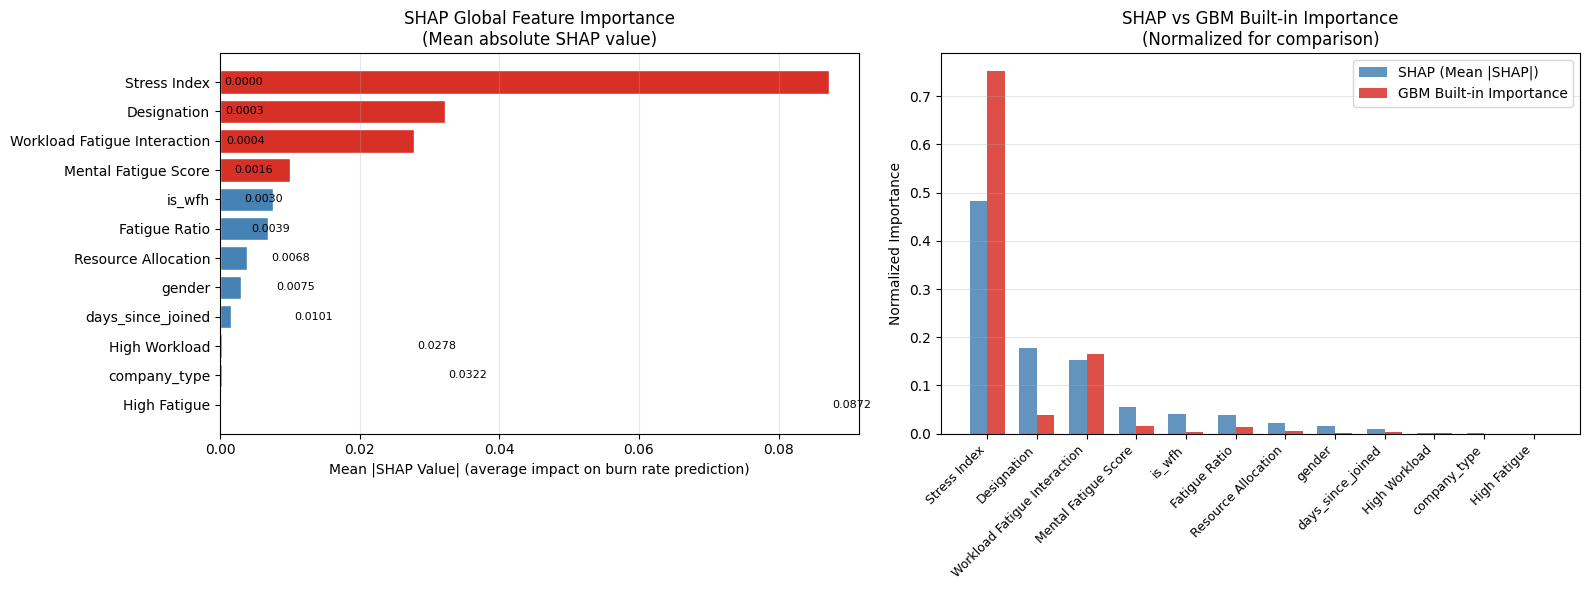


SHAP Feature Importance Rankings:
                         Feature  Mean |SHAP|
0                   Stress Index     0.087186
1                    Designation     0.032210
2   Workload Fatigue Interaction     0.027810
3           Mental Fatigue Score     0.010082
4                         is_wfh     0.007534
5                  Fatigue Ratio     0.006837
6            Resource Allocation     0.003938
7                         gender     0.002953
8              days_since_joined     0.001597
9                  High Workload     0.000351
10                  company_type     0.000282
11                  High Fatigue     0.000048


In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

# Also get GBM built-in importance for comparison
builtin_imp = pd.Series(gb_model.feature_importances_, index=feature_cols)
shap_importance['GBM Built-in'] = shap_importance['Feature'].map(builtin_imp)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: SHAP importance
colors = ['#d73027' if i < 4 else 'steelblue' for i in range(len(shap_importance))]
bars = axes[0].barh(
    shap_importance['Feature'][::-1],
    shap_importance['Mean |SHAP|'][::-1],
    color=colors[::-1], edgecolor='white'
)
axes[0].set_xlabel("Mean |SHAP Value| (average impact on burn rate prediction)", fontsize=10)
axes[0].set_title("SHAP Global Feature Importance\n(Mean absolute SHAP value)", fontsize=12)
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars[::-1], shap_importance['Mean |SHAP|'][::-1]):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)

# Right: SHAP vs GBM built-in importance side-by-side
x = np.arange(len(shap_importance))
w = 0.35
shap_norm = shap_importance['Mean |SHAP|'] / shap_importance['Mean |SHAP|'].sum()
builtin_norm = shap_importance['GBM Built-in'] / shap_importance['GBM Built-in'].sum()

axes[1].bar(x - w/2, shap_norm, w, label='SHAP (Mean |SHAP|)', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, builtin_norm, w, label='GBM Built-in Importance', color='#d73027', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(shap_importance['Feature'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel("Normalized Importance", fontsize=10)
axes[1].set_title("SHAP vs GBM Built-in Importance\n(Normalized for comparison)", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSHAP Feature Importance Rankings:")
print(shap_importance[['Feature','Mean |SHAP|']].to_string(index=True))

## SHAP Summary Plot (Beeswarm)

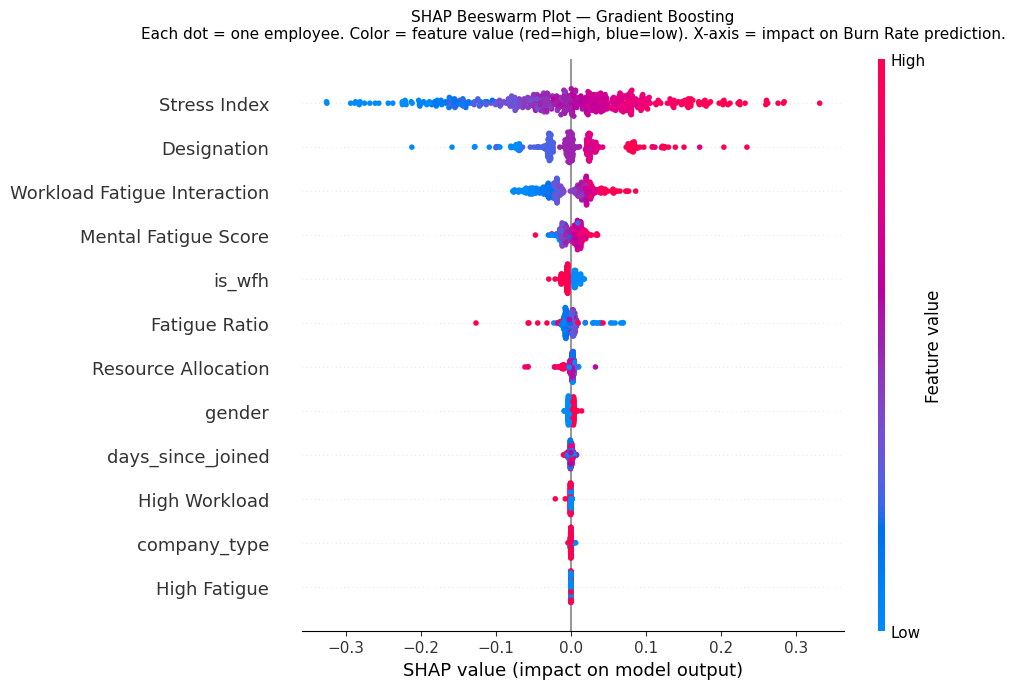

In [11]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols,
    plot_type="dot",
    max_display=12,
    show=False,
    plot_size=None
)
plt.title("SHAP Beeswarm Plot — Gradient Boosting\n"
          "Each dot = one employee. Color = feature value (red=high, blue=low). "
          "X-axis = impact on Burn Rate prediction.",
          fontsize=11, pad=15)
plt.tight_layout()
plt.show()

## SHAP Dependence Plots Top Features

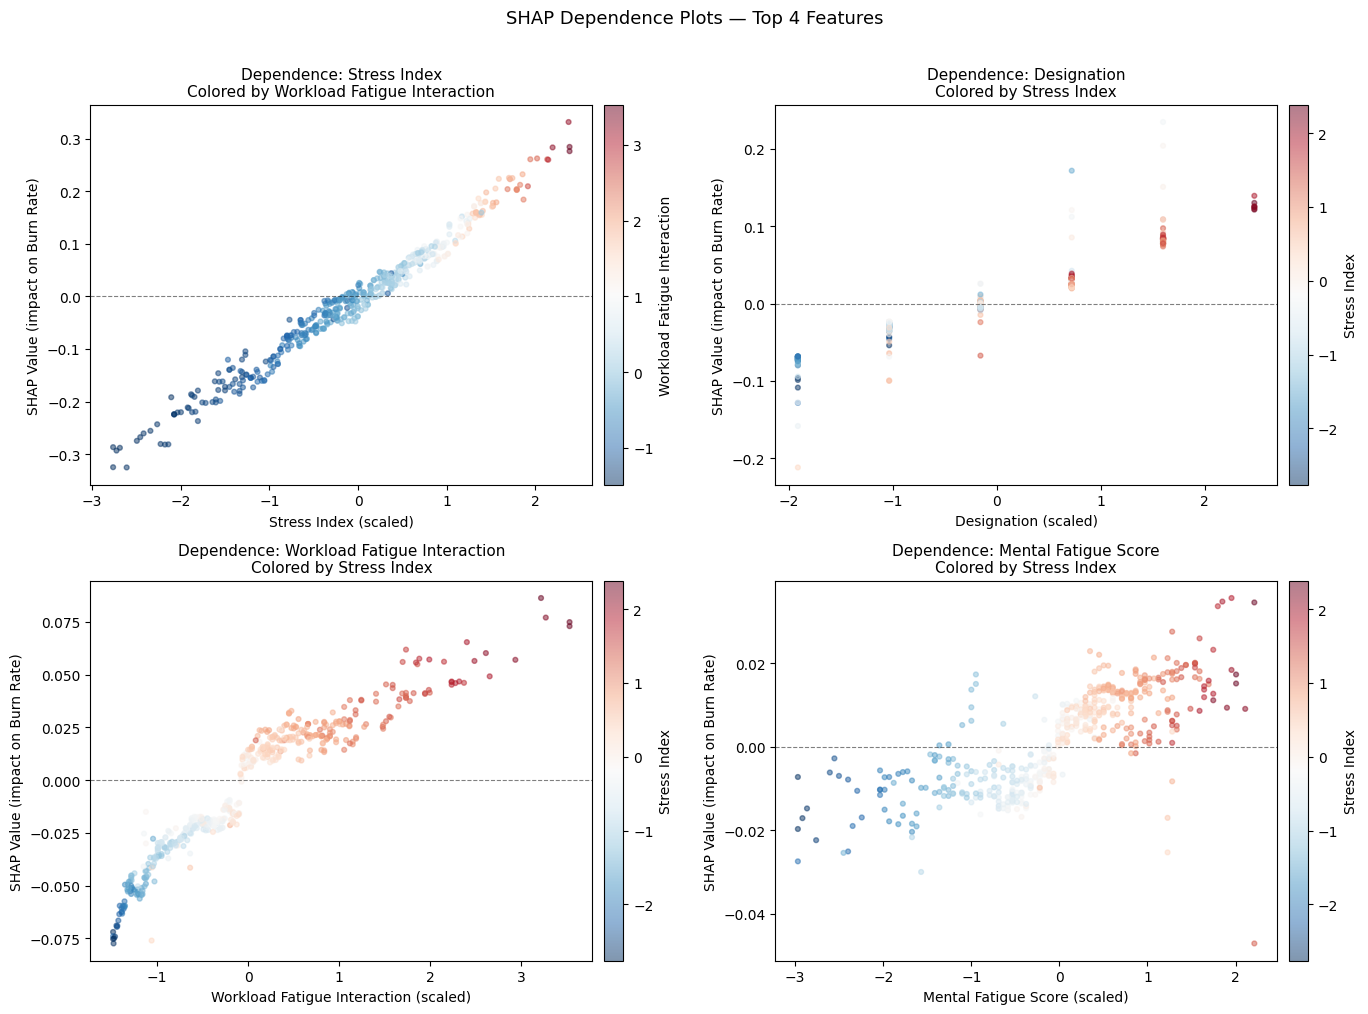

In [12]:
top_features = shap_importance['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = feature_cols.index(feat)
    feat_vals = X_shap[feat].values
    shap_feat = shap_values[:, feat_idx]

    # Color by Stress Index (best interaction partner for top burnout features)
    color_feat = "Stress Index" if feat != "Stress Index" else "Workload Fatigue Interaction"
    color_vals = X_shap[color_feat].values

    sc = axes[i].scatter(
        feat_vals, shap_feat,
        c=color_vals, cmap='RdBu_r', alpha=0.5, s=12
    )
    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[i].set_xlabel(f"{feat} (scaled)", fontsize=10)
    axes[i].set_ylabel("SHAP Value (impact on Burn Rate)", fontsize=10)
    axes[i].set_title(f"Dependence: {feat}\nColored by {color_feat}", fontsize=11)
    plt.colorbar(sc, ax=axes[i], label=color_feat, pad=0.02)

plt.suptitle("SHAP Dependence Plots — Top 4 Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## SHAP Force Plot Individual Predictions

In [13]:
preds_shap = gb_model.predict(X_shap)

# Finding representative examples
high_idx   = np.argmax(preds_shap)          # highest predicted burn rate
low_idx    = np.argmin(preds_shap)           # lowest predicted burn rate
mid_idx    = np.argmin(np.abs(preds_shap - np.median(preds_shap)))  # closest to median

case_labels = {
    high_idx: ("HIGH Burnout", "#d73027"),
    low_idx:  ("LOW Burnout",  "steelblue"),
    mid_idx:  ("MODERATE Burnout", "#f4a261"),
}

for idx, (label, color) in case_labels.items():
    print(f"\n{'='*55}")
    print(f"Case: {label}")
    print(f"  Predicted Burn Rate : {preds_shap[idx]:.4f}")
    print(f"  Model baseline      : {expected_value:.4f}")
    print(f"  Net SHAP effect     : {shap_values[idx].sum():+.4f}")
    print(f"\n  Feature Contributions (sorted by magnitude):")
    contributions = sorted(
        zip(feature_cols, shap_values[idx], X_shap.iloc[idx]),
        key=lambda x: abs(x[1]), reverse=True
    )
    for feat, sv, fv in contributions[:8]:
        direction = "↑ increases" if sv > 0 else "↓ decreases"
        print(f"    {feat:<35} value={fv:+.2f}  SHAP={sv:+.4f}  ({direction} burnout)")


Case: HIGH Burnout
  Predicted Burn Rate : 0.9414
  Model baseline      : 0.4522
  Net SHAP effect     : +0.4892

  Feature Contributions (sorted by magnitude):
    Stress Index                        value=+2.37  SHAP=+0.3315  (↑ increases burnout)
    Workload Fatigue Interaction        value=+3.22  SHAP=+0.0864  (↑ increases burnout)
    Mental Fatigue Score                value=+2.21  SHAP=+0.0346  (↑ increases burnout)
    Designation                         value=+0.72  SHAP=+0.0327  (↑ increases burnout)
    Resource Allocation                 value=+2.20  SHAP=-0.0122  (↓ decreases burnout)
    gender                              value=+1.05  SHAP=+0.0069  (↑ increases burnout)
    is_wfh                              value=-1.08  SHAP=+0.0064  (↑ increases burnout)
    Fatigue Ratio                       value=-0.45  SHAP=+0.0042  (↑ increases burnout)

Case: LOW Burnout
  Predicted Burn Rate : 0.0008
  Model baseline      : 0.4522
  Net SHAP effect     : -0.4515

  Feature Co

## SHAP Waterfall Charts CasebyCase Breakdown

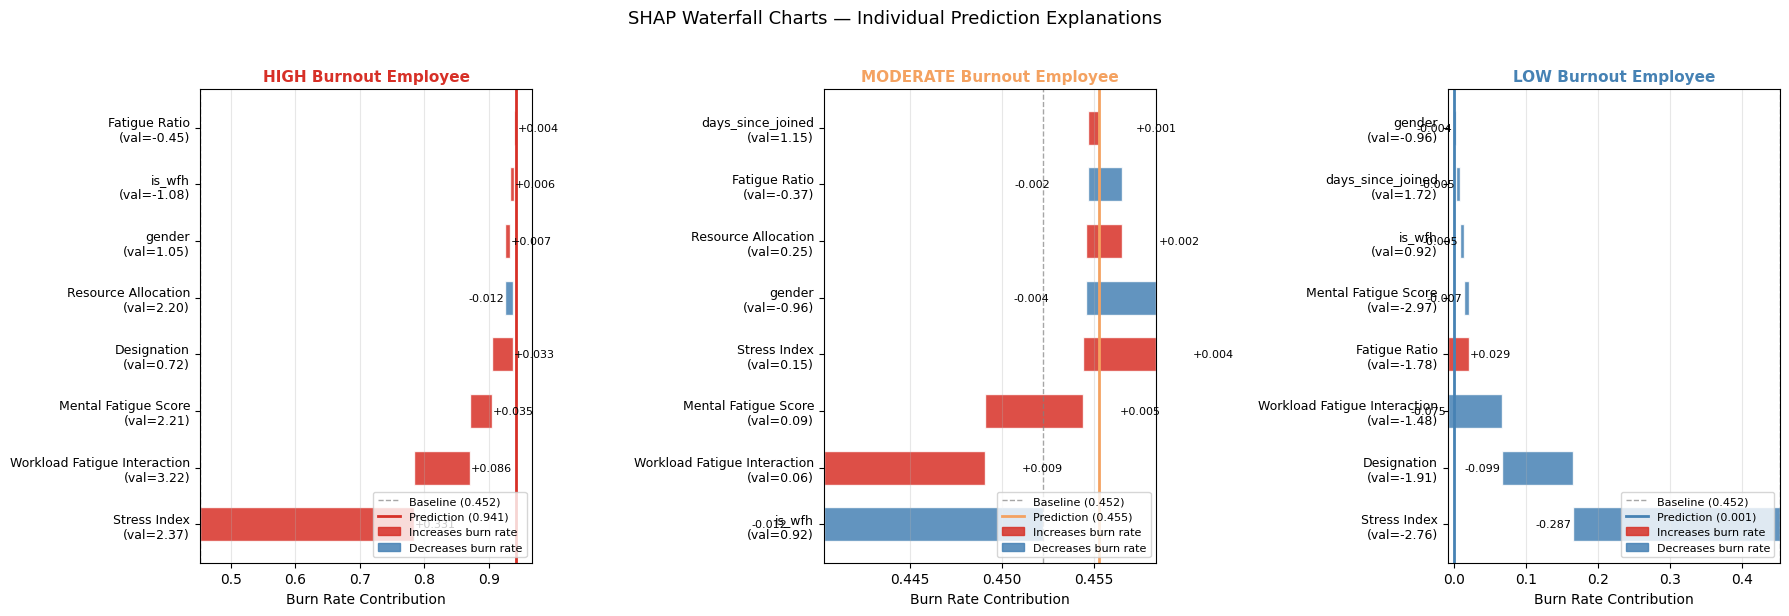

In [14]:
def waterfall_chart(ax, shap_vals, feature_names, feature_values, expected, prediction, title, color):
    """Custom waterfall chart showing SHAP contributions per feature."""
    # Sorting by absolute SHAP value, show top 8
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:8]
    names  = [feature_names[i] for i in sorted_idx]
    values = [shap_vals[i] for i in sorted_idx]
    fvals  = [feature_values[i] for i in sorted_idx]

    # Build running total
    cumulative = [expected]
    for v in values:
        cumulative.append(cumulative[-1] + v)

    bar_colors = ['#d73027' if v > 0 else 'steelblue' for v in values]
    y_pos = np.arange(len(values))

    for i, (name, val, fval, color_b) in enumerate(zip(names, values, fvals, bar_colors)):
        ax.barh(i, val, left=cumulative[i], color=color_b, alpha=0.85, edgecolor='white', height=0.6)
        ax.text(cumulative[i] + val + (0.002 if val > 0 else -0.002),
                i, f"{val:+.3f}", va='center', ha='left' if val > 0 else 'right', fontsize=8)

    ax.axvline(expected, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Baseline ({expected:.3f})')
    ax.axvline(prediction, color=color, linestyle='-', linewidth=2, label=f'Prediction ({prediction:.3f})')

    labels = [f"{n}\n(val={v:.2f})" for n, v in zip(names, fvals)]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Burn Rate Contribution", fontsize=10)
    ax.set_title(title, fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

    red_patch   = mpatches.Patch(color='#d73027', alpha=0.85, label='Increases burn rate')
    blue_patch  = mpatches.Patch(color='steelblue', alpha=0.85, label='Decreases burn rate')
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles=handles + [red_patch, blue_patch], fontsize=8, loc='lower right')


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cases = [
    (high_idx, "HIGH Burnout Employee",     "#d73027"),
    (mid_idx,  "MODERATE Burnout Employee", "#f4a261"),
    (low_idx,  "LOW Burnout Employee",      "steelblue"),
]

for ax, (idx, title, color) in zip(axes, cases):
    waterfall_chart(
        ax,
        shap_values[idx],
        feature_cols,
        X_shap.iloc[idx].values,
        expected_value,
        preds_shap[idx],
        title,
        color
    )

plt.suptitle("SHAP Waterfall Charts — Individual Prediction Explanations",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## SHAP Interaction: WFH Effect Across Seniority

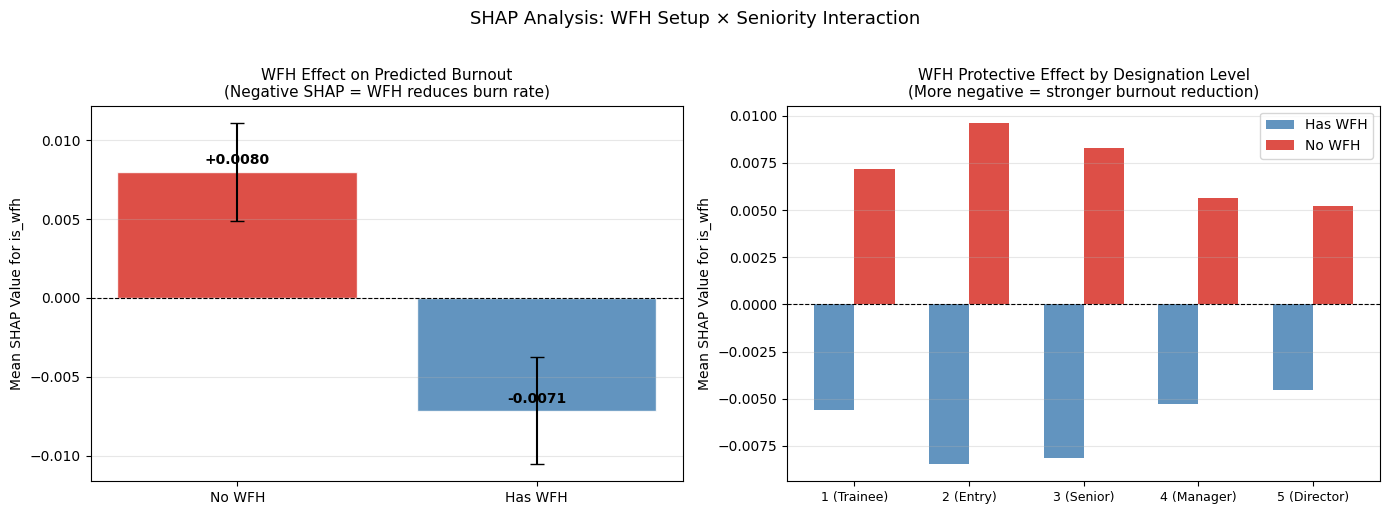

In [15]:
wfh_idx  = feature_cols.index("is_wfh")
des_idx  = feature_cols.index("Designation")

# is_wfh is scaled so 0→negative, 1→positive; use threshold at 0 to split groups
wfh_has    = X_shap['is_wfh'] > 0
wfh_no     = X_shap['is_wfh'] <= 0

# Unscale Designation for readable labels
des_unscaled = scaler.inverse_transform(X_shap)[:, des_idx]
des_bins = pd.cut(des_unscaled, bins=[0, 1.5, 2.5, 3.5, 4.5, 5.5],
                  labels=["1 (Trainee)", "2 (Entry)", "3 (Senior)", "4 (Manager)", "5 (Director)"])

shap_df = pd.DataFrame({
    'is_wfh_has': wfh_has.values,
    'is_wfh_shap': shap_values[:, wfh_idx],
    'Designation_group': des_bins
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: WFH SHAP by WFH status
wfh_grouped = shap_df.groupby('is_wfh_has')['is_wfh_shap'].agg(['mean', 'std'])
wfh_labels  = ['No WFH', 'Has WFH']
wfh_colors  = ['#d73027', 'steelblue']
bars = axes[0].bar(wfh_labels, wfh_grouped['mean'], yerr=wfh_grouped['std'],
                   color=wfh_colors, alpha=0.85, edgecolor='white', capsize=5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_ylabel("Mean SHAP Value for is_wfh", fontsize=10)
axes[0].set_title("WFH Effect on Predicted Burnout\n"
                  "(Negative SHAP = WFH reduces burn rate)", fontsize=11)
for bar, (mean_v, _) in zip(bars, wfh_grouped.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, mean_v + 0.0003,
                 f"{mean_v:+.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: WFH SHAP broken down by Designation
des_wfh    = shap_df[shap_df['is_wfh_has']==True].groupby('Designation_group')['is_wfh_shap'].mean()
des_no_wfh = shap_df[shap_df['is_wfh_has']==False].groupby('Designation_group')['is_wfh_shap'].mean()

x_des = np.arange(len(des_wfh.index))
w = 0.35
axes[1].bar(x_des - w/2, des_wfh.values, w, label='Has WFH', color='steelblue', alpha=0.85)
axes[1].bar(x_des + w/2, des_no_wfh.values, w, label='No WFH', color='#d73027', alpha=0.85)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticks(x_des)
axes[1].set_xticklabels(des_wfh.index, fontsize=9)
axes[1].set_ylabel("Mean SHAP Value for is_wfh", fontsize=10)
axes[1].set_title("WFH Protective Effect by Designation Level\n"
                  "(More negative = stronger burnout reduction)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("SHAP Analysis: WFH Setup × Seniority Interaction", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()